# Publication Figures

Figures for [Tracking a symbolic reasoning circuit from failure to success](https://www.lesswrong.com/posts/6FuRGhKxaSB9dPmZz/tracking-a-symbolic-reasoning-circuit-from-failure-to):
tracking how gemma-2-2b's three-stage symbolic reasoning circuit (Yang et al., 2025)
changes as the model goes from ~50% accuracy at 2-shot to ~99% at 10-shot.

**Figures:**
1. Accuracy across shot counts (ABA vs ABB, 1–10 shot)
2. CMA score heatmaps (layer × head, across shot counts and circuit stages)
3. Rescue patching (significant heads by stage, correct→incorrect patching)

In [20]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D
from pathlib import Path

# Paths
RESULTS = Path('../../../results/shot_sweep')
FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)

# Publication style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8
})

# Color palette
STAGE_COLORS = {'SA': '#4C72B0', 'SI': '#DD8452', 'Ret': '#55A868'}
STAGE_NAMES = {
    'SA': 'Symbol Abstraction (SA)',
    'SI': 'Symbolic Induction (SI)',
    'Ret': 'Retrieval (Ret)'
}
RULE_COLORS = {'ABA': '#C44E52', 'ABB': '#4C72B0'}
STAGE_MAP = {
    'symbol_abstraction': 'SA',
    'symbolic_induction': 'SI',
    'retrieval': 'Ret'
}
STAGE_ORDER = {'SA': 0, 'SI': 1, 'Ret': 2}
SHOT_COUNTS_CMA = [2, 4, 10]

In [21]:
# === Load all data ===

import torch

# Accuracy sweep
with open(RESULTS / 'accuracy_sweep.json') as f:
    acc_raw = json.load(f)

shots_all = sorted(int(s) for s in acc_raw['results'])
acc = {}
for rule in ['ABA', 'ABB']:
    acc[rule] = {
        'acc': [acc_raw['results'][str(s)][rule]['accuracy'] for s in shots_all],
        'ci_lo': [acc_raw['results'][str(s)][rule]['ci_95_low'] for s in shots_all],
        'ci_hi': [acc_raw['results'][str(s)][rule]['ci_95_high'] for s in shots_all],
    }

# CMA significant heads at 2, 4, 10 shot
sig_heads = {}
for n in SHOT_COUNTS_CMA:
    with open(RESULTS / f'{n}shot' / 'significant_heads.json') as f:
        sig_heads[n] = json.load(f)

# Build unified head registry: assign each head to its peak CMA stage
head_best_stage = {}  # (L,H) -> (stage, best_score)

for n in SHOT_COUNTS_CMA:
    for key, hlist in sig_heads[n].items():
        stage = STAGE_MAP[key.rsplit('_base_', 1)[0]]
        for h in hlist:
            hk = (h['layer'], h['head'])
            if hk not in head_best_stage or h['score'] > head_best_stage[hk][1]:
                head_best_stage[hk] = (stage, h['score'])

head_stage = {k: v[0] for k, v in head_best_stage.items()}

# Stage masks: each head assigned to exactly one stage (its peak CMA role)
global_stage_mask = {}
for s in ['SA', 'SI', 'Ret']:
    mask = np.zeros((26, 8), dtype=bool)
    for (L, H), stage in head_stage.items():
        if stage == s:
            mask[L, H] = True
    global_stage_mask[s] = mask

# CMA-significant at ANY shot count
any_cma_sig = np.zeros((26, 8), dtype=bool)
for n in SHOT_COUNTS_CMA:
    for key, hlist in sig_heads[n].items():
        for h in hlist:
            any_cma_sig[h['layer'], h['head']] = True

# Rescue patching data (2-shot and 4-shot)
rescue_shots = [2, 4]
rescue_prob_delta = {}
rescue_sig = {}

for n in rescue_shots:
    rescue_prob_delta[n] = torch.load(
        RESULTS / f'{n}shot' / 'rescue' / 'prob_delta_aba.pt',
        map_location='cpu',
    ).float().numpy()
    rescue_sig[n] = torch.load(
        RESULTS / f'{n}shot' / 'rescue' / 'rescue_sig_aba.pt',
        map_location='cpu',
    ).numpy()

print(f'Shot counts: {shots_all}')
print(f'Total unique CMA heads: {len(head_stage)}')
for n in rescue_shots:
    n_sig = rescue_sig[n].sum()
    n_pos = (rescue_sig[n] & (rescue_prob_delta[n] > 0)).sum()
    n_neg = (rescue_sig[n] & (rescue_prob_delta[n] < 0)).sum()
    print(f'{n}-shot rescue: {n_sig} significant (q < 0.05) — {n_pos} positive, {n_neg} negative')

Shot counts: [1, 2, 3, 4, 5, 6, 8, 10]
Total unique CMA heads: 34
2-shot rescue: 95 significant (q < 0.05) — 47 positive, 48 negative
4-shot rescue: 77 significant (q < 0.05) — 49 positive, 28 negative


## Figure 1: Accuracy Emergence

ABA and ABB accuracy vs. shot count (1–10). ABA climbs sharply from ~19% at
1-shot to ~93% at 4-shot. ABB starts higher and saturates faster. Both
converge to ~99% by 10-shot. Shaded regions show 95% confidence intervals.

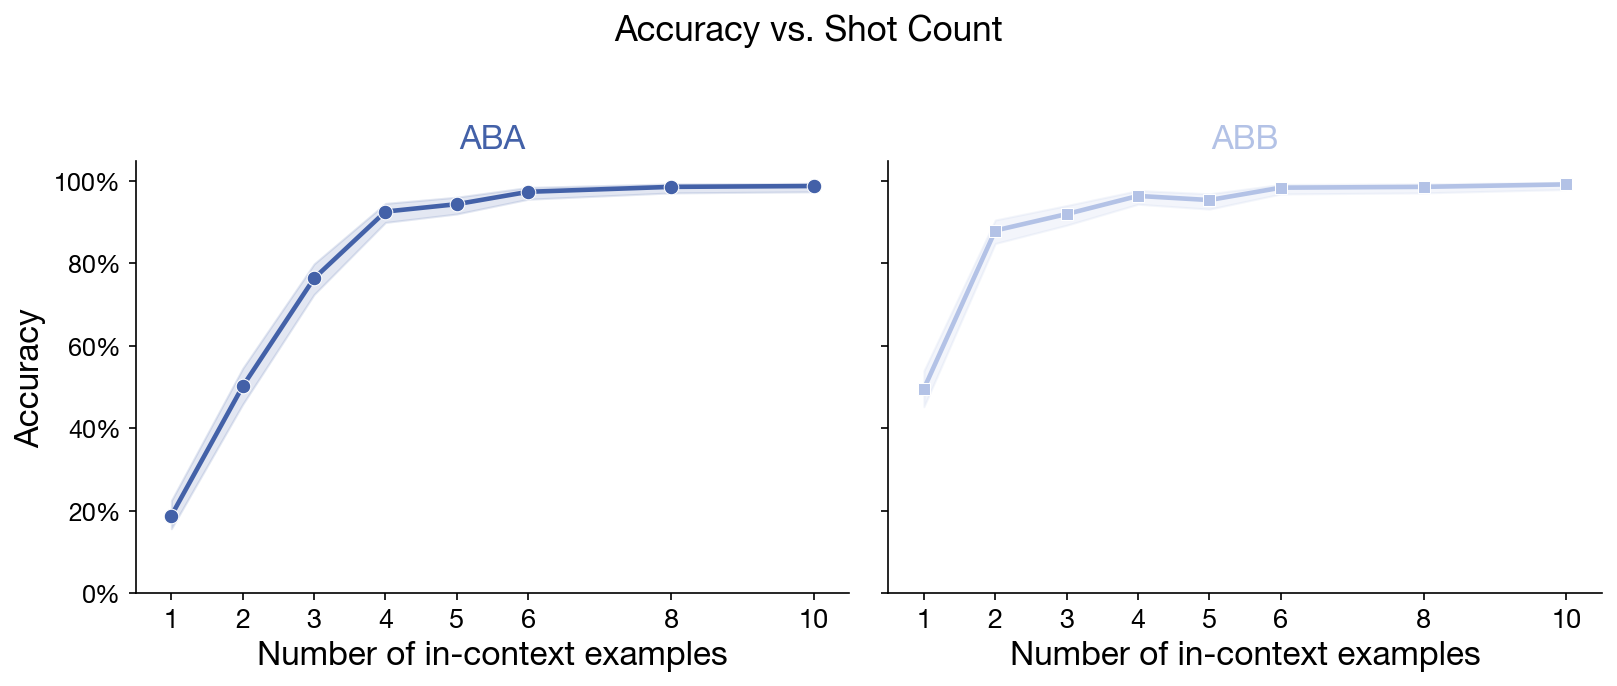

In [22]:
# Updated colors: darker blue for ABA, lighter blue for ABB
ABA_COLOR = '#4361a8'
ABB_COLOR = '#b3c2e6'

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, (rule, color, marker, ms) in zip(axes,
        [('ABA', ABA_COLOR, 'o', 7), ('ABB', ABB_COLOR, 's', 6)]):
    y = np.array(acc[rule]['acc'])
    lo = np.array(acc[rule]['ci_lo'])
    hi = np.array(acc[rule]['ci_hi'])
    ax.plot(shots_all, y, marker=marker, color=color, lw=2.2, markersize=ms,
            zorder=3, markeredgecolor='white', markeredgewidth=0.5)
    ax.fill_between(shots_all, lo, hi, alpha=0.15, color=color, zorder=2)

    ax.set_xlabel('Number of in-context examples')
    ax.set_xticks(shots_all)
    ax.set_xlim(0.5, 10.5)
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_title(rule, fontweight='bold', color=color)

axes[0].set_ylabel('Accuracy')

fig.suptitle('Accuracy vs. Shot Count', fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / 'fig1_accuracy_emergence.pdf')
fig.savefig(FIGURES / 'fig1_accuracy_emergence.png')
plt.show()

## Figure 2: CMA Score Heatmaps (Layer × Head)

3×3 grid of full layer×head heatmaps. Columns = circuit stage (SA, SI, Ret),
rows = shot count (2, 4, 10). Each cell shows the mean CMA score (max across
ABA/ABB rules) for every layer-head pair. Color scale shared within each
column so amplification across shots is directly visible.

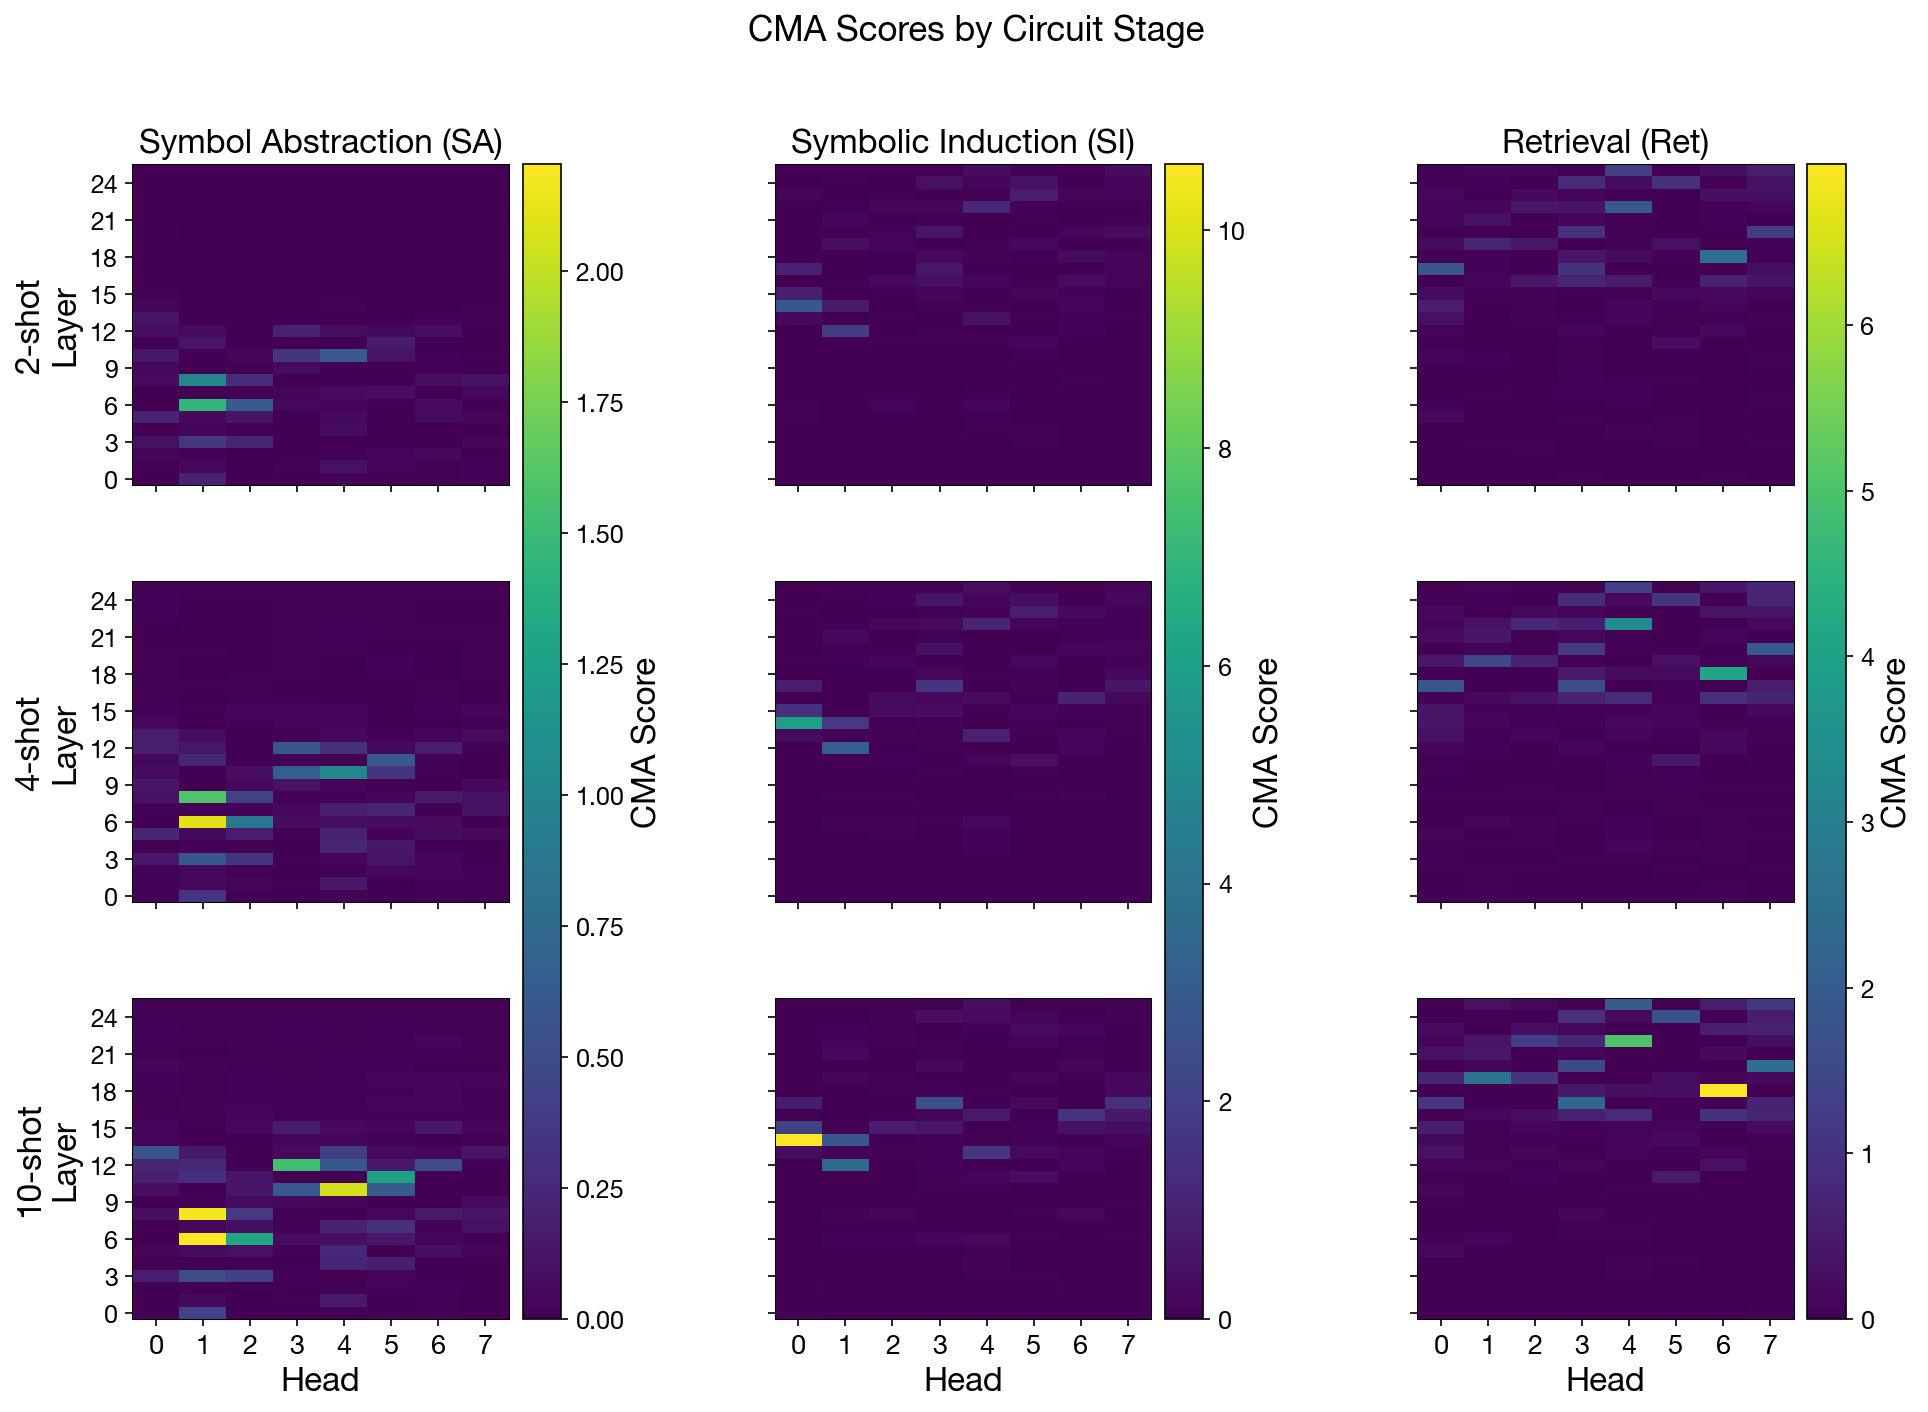

In [4]:
# Stage -> (subdirectory, tensor prefix)
stage_tensor_info = {
    'SA': ('abstract', 'symbol_abstraction'),
    'SI': ('abstract', 'symbolic_induction'),
    'Ret': ('token', 'retrieval'),
}

# Load raw CMA grids: mean across pairs, max across rules -> [26, 8]
cma_grids = {}
for n in SHOT_COUNTS_CMA:
    for s in ['SA', 'SI', 'Ret']:
        subdir, prefix = stage_tensor_info[s]
        rule_grids = []
        for rule in ['aba', 'abb']:
            path = RESULTS / f'{n}shot' / 'cma' / subdir / f'{prefix}_scores_base_{rule}.pt'
            raw = torch.load(path, map_location='cpu')
            rule_grids.append(raw.float().mean(dim=0).numpy())  # [26, 8]
        cma_grids[(n, s)] = np.maximum(rule_grids[0], rule_grids[1])

# 3x3 grid: rows = shot count, columns = stage
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.3)

stages_order = ['SA', 'SI', 'Ret']

for col, s in enumerate(stages_order):
    # Per-column color scale so amplification is visible across rows
    col_vmax = max(cma_grids[(n, s)].max() for n in SHOT_COUNTS_CMA)
    last_im = None

    for row, n in enumerate(SHOT_COUNTS_CMA):
        ax = axes[row, col]
        grid = cma_grids[(n, s)]

        im = ax.imshow(grid, aspect='auto', cmap='viridis',
                       origin='lower', vmin=0, vmax=col_vmax)
        last_im = im

        # All spines visible for heatmap cells
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)

        # Y-axis: layers
        ax.set_yticks(range(0, 26, 3))
        if col == 0:
            ax.set_ylabel(f'{n}-shot\nLayer')
        else:
            ax.set_yticklabels([])

        # X-axis: heads
        ax.set_xticks(range(8))
        if row == 2:
            ax.set_xticklabels(range(8))
            ax.set_xlabel('Head')
        else:
            ax.set_xticklabels([])

        # Column titles (top row only)
        if row == 0:
            ax.set_title(STAGE_NAMES[s], fontweight='bold')

    # Per-column colorbar — match column height, keep narrow
    fig.colorbar(last_im, ax=axes[:, col].tolist(), shrink=1.0,
                 aspect=30, label='CMA Score', pad=0.03)

fig.suptitle('CMA Scores by Circuit Stage', fontweight='bold')
fig.savefig(FIGURES / 'fig2_cma_heatmap.pdf')
fig.savefig(FIGURES / 'fig2_cma_heatmap.png')
plt.show()

## Figure 3: Rescue Patching — Significance-Tested (Layer × Head)

2×3 grid: rows = shot count (2, 4), columns = circuit stage (SA, SI, Ret).
Each head is assigned to exactly one stage based on its peak CMA contribution
across all shot counts, so heads that shift roles appear in their mature stage
column. Masked to heads passing both CMA permutation test (p < 0.05, at any
shot count) and rescue Wilcoxon signed-rank test (two-sided, FDR q < 0.05).
RdBu diverging colormap: red = negative Δ (harmful), blue = positive Δ (rescues).

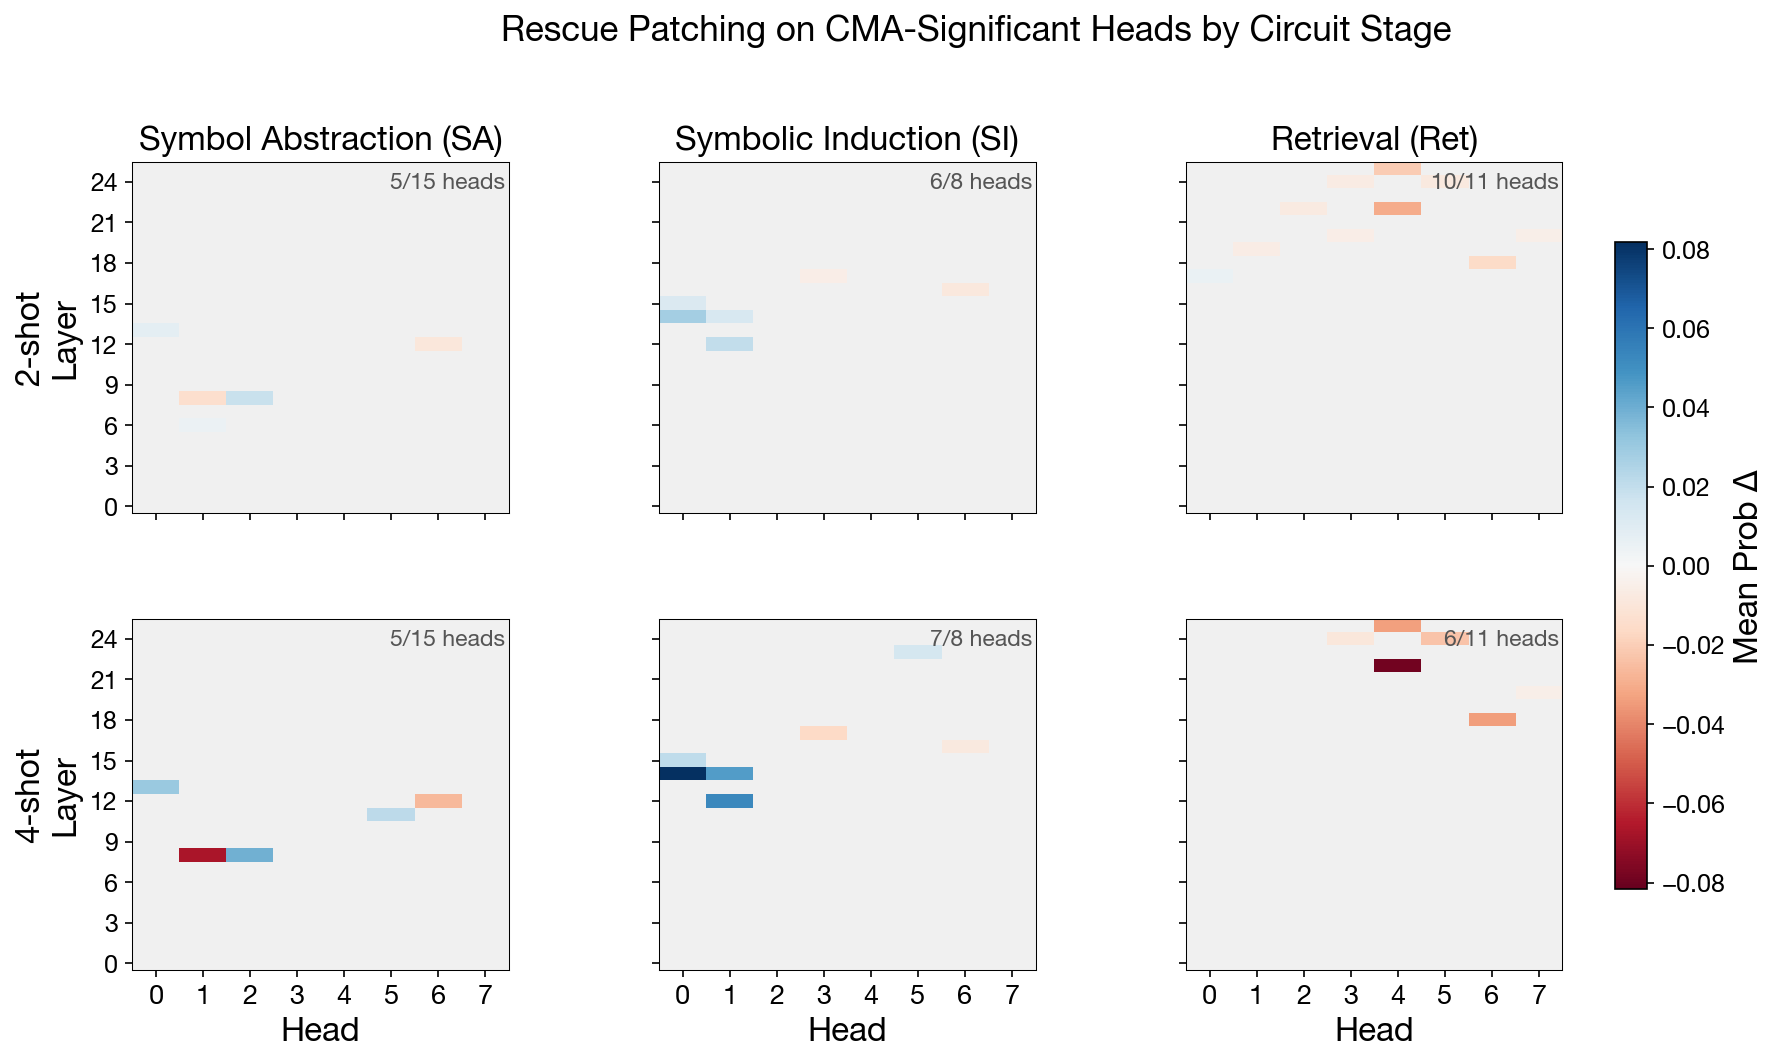

In [5]:
# --- Plot: 2x3 grid (shot count × stage), rescue-sig ∩ CMA-sig, one stage per head ---
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.subplots_adjust(wspace=0.4, hspace=0.3)

stages_order = ['SA', 'SI', 'Ret']

# Global diverging scale from doubly-significant values
all_vals = []
for n in rescue_shots:
    for s in stages_order:
        combined = global_stage_mask[s] & any_cma_sig & rescue_sig[n]
        vals = rescue_prob_delta[n][combined]
        if len(vals) > 0:
            all_vals.append(vals)
if len(all_vals) > 0:
    all_vals = np.concatenate(all_vals)
    abs_max = np.max(np.abs(all_vals))
else:
    abs_max = 0.1

# RdBu (not _r): red = negative (harmful), blue = positive (rescues)
cmap = plt.cm.RdBu.copy()
cmap.set_bad('#f0f0f0')

last_im = None
for col, s in enumerate(stages_order):
    for row, n in enumerate(rescue_shots):
        ax = axes[row, col]
        grid = rescue_prob_delta[n].copy()

        # Mask: head's best stage == this column AND ever CMA-sig AND rescue-sig now
        combined_mask = global_stage_mask[s] & any_cma_sig & rescue_sig[n]
        masked = np.where(combined_mask, grid, np.nan)
        masked_ma = np.ma.masked_invalid(masked)

        im = ax.imshow(masked_ma, aspect='auto', cmap=cmap,
                       origin='lower', vmin=-abs_max, vmax=abs_max)
        last_im = im

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)

        # Y-axis: layers
        ax.set_yticks(range(0, 26, 3))
        if col == 0:
            ax.set_ylabel(f'{n}-shot\nLayer')
        else:
            ax.set_yticklabels([])

        # X-axis: heads
        ax.set_xticks(range(8))
        if row == 1:
            ax.set_xticklabels(range(8))
            ax.set_xlabel('Head')
        else:
            ax.set_xticklabels([])

        # Column titles (top row only)
        if row == 0:
            ax.set_title(STAGE_NAMES[s], fontweight='bold')

        # Count heads shown vs total in this stage
        n_shown = combined_mask.sum()
        n_stage = (global_stage_mask[s] & any_cma_sig).sum()
        ax.text(0.99, 0.97, f'{n_shown}/{n_stage} heads',
                transform=ax.transAxes, fontsize=11, color='#555555',
                ha='right', va='top')

# Single colorbar
fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.8,
             label='Mean Prob Δ', pad=0.03)

fig.suptitle('Rescue Patching on CMA-Significant Heads by Circuit Stage', fontweight='bold', y=1.02)
fig.savefig(FIGURES / 'fig3_rescue_significant.pdf')
fig.savefig(FIGURES / 'fig3_rescue_significant.png')
plt.show()